In [101]:
import os
import random
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

In [102]:
# -----------------------------
# UNet generator (GroupNorm stable)
# -----------------------------
def _group_norm(channels):
    # choose groups: min(32, channels) but must divide channels. Choose divisor near 32.
    groups = min(32, channels)
    # reduce groups until divides channels
    while channels % groups != 0:
        groups -= 1
        if groups == 1:
            break
    return nn.GroupNorm(groups, channels)

class UNetGenerator(nn.Module):
    def __init__(self, in_channels=1, out_channels=3, base_features=64, depth=4, use_norm=True):
        super().__init__()
        assert depth >= 1, "depth must be >= 1"
        self.depth = depth
        self.use_norm = use_norm
        self.encs = nn.ModuleList()
        self.encoder_channels = []

        prev_ch = in_channels
        for i in range(depth):
            out_ch = base_features * (2**i)
            layers = [nn.Conv2d(prev_ch, out_ch, 4, 2, 1)]
            # first encoder typically no norm, use LeakyReLU
            if use_norm and i != 0:
                layers.append(_group_norm(out_ch))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            self.encs.append(nn.Sequential(*layers))
            self.encoder_channels.append(out_ch)
            prev_ch = out_ch

        # decoder
        self.decs = nn.ModuleList()
        cur_in = self.encoder_channels[-1]
        for enc_ch in reversed(self.encoder_channels[:-1]):
            out_ch = enc_ch
            layers = [nn.ConvTranspose2d(cur_in, out_ch, 4, 2, 1)]
            if use_norm:
                layers.append(_group_norm(out_ch))
            layers.append(nn.ReLU(inplace=True))
            self.decs.append(nn.Sequential(*layers))
            cur_in = out_ch * 2

        self.final = nn.ConvTranspose2d(cur_in, out_channels, 4, 2, 1)
        self.out_act = nn.Sigmoid()  # because we use 0..1 targets

    def forward(self, x):
        skips = []
        out = x
        for enc in self.encs:
            out = enc(out)
            skips.append(out)
        for i, dec in enumerate(self.decs):
            out = dec(out)
            skip = skips[-(i+2)]
            if out.shape[2:] != skip.shape[2:]:
                out = nn.functional.interpolate(out, size=skip.shape[2:], mode="bilinear", align_corners=False)
            out = torch.cat([out, skip], dim=1)
        out = self.final(out)
        return self.out_act(out)

In [103]:
to_tensor = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

to_pil = transforms.ToPILImage()
device = "cuda" if torch.cuda.is_available() else "cpu"


def generate_from_sketch(img, model=G):
    # Resize and convert to grayscale 0–1 tensor
    print(img)
    print(type(img))
    img = img.convert("L").resize((128, 128))
    x = to_tensor(img).unsqueeze(0).to(device)

    with torch.no_grad():
        generated = model(x).squeeze(0).cpu()
        generated = generated.clamp(0, 1)
    generated_img = to_pil(generated)
    return generated_img


<PIL.JpegImagePlugin.JpegImageFile image mode=L size=256x256 at 0x2770B0CB950>
<class 'PIL.JpegImagePlugin.JpegImageFile'>


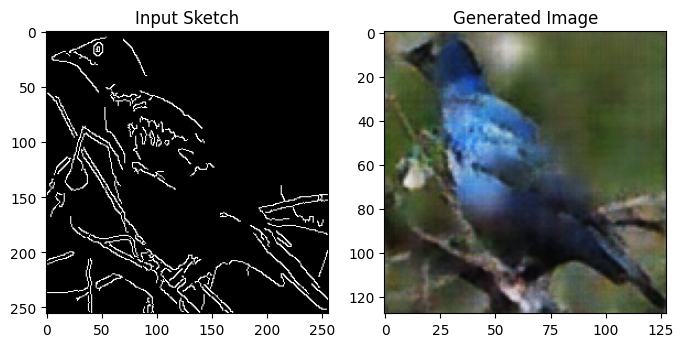

In [107]:
# get random image from /data_prepared/valid/inputs/ directory
input_dir = "data_prepared/valid/inputs"

model_path = "valid_generator_model.pth"  # adjust if needed
G = UNetGenerator().to(device)
state_dict = torch.load(model_path, map_location=device)
G.load_state_dict(state_dict, strict=False)
#G.eval()
G.train()


random_file = random.choice(os.listdir(input_dir))
input_image = Image.open(os.path.join(input_dir, random_file))
generated_image = generate_from_sketch(input_image, model=G)
fig, axs = plt.subplots(1, 2, figsize=(8, 4))
axs[0].imshow(input_image.convert("L"), cmap="gray")
axs[0].set_title("Input Sketch")
axs[1].imshow(generated_image)
axs[1].set_title("Generated Image")
plt.show()

In [80]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model_path = "overfitted_generator_model.pth"  # adjust if needed
G = UNetGenerator().to(device)
state_dict = torch.load(model_path, map_location=device)
G.load_state_dict(state_dict, strict=True)
G.eval()

UNetGenerator(
  (encs): ModuleList(
    (0): Sequential(
      (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): LeakyReLU(negative_slope=0.2, inplace=True)
    )
    (1): Sequential(
      (0): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): GroupNorm(32, 128, eps=1e-05, affine=True)
      (2): LeakyReLU(negative_slope=0.2, inplace=True)
    )
    (2): Sequential(
      (0): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): GroupNorm(32, 256, eps=1e-05, affine=True)
      (2): LeakyReLU(negative_slope=0.2, inplace=True)
    )
    (3): Sequential(
      (0): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): GroupNorm(32, 512, eps=1e-05, affine=True)
      (2): LeakyReLU(negative_slope=0.2, inplace=True)
    )
  )
  (decs): ModuleList(
    (0): Sequential(
      (0): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): GroupNorm(32, 2

<PIL.Image.Image image mode=L size=128x128 at 0x2771D65BB10>
<class 'PIL.Image.Image'>


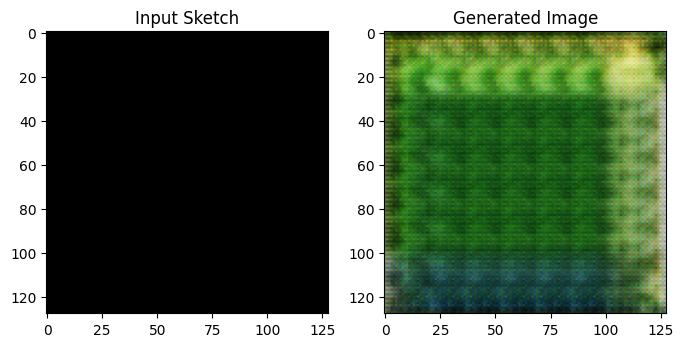

In [81]:
# generate blank 128x128 image
blank_image = Image.new("L", (128, 128), 255)

# show input image and output image side by side using matplotlib
fig, axs = plt.subplots(1, 2, figsize=(8, 4))
axs[0].imshow(blank_image, cmap="gray")
axs[0].set_title("Input Sketch")
generated_image = generate_from_sketch(blank_image)
axs[1].imshow(generated_image)
axs[1].set_title("Generated Image")
plt.show()

<PIL.Image.Image image mode=L size=128x128 at 0x2771A130AF0>
<class 'PIL.Image.Image'>


C:\Users\EGE\AppData\Local\Temp\ipykernel_36856\2292774749.py:3: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  blank_image = Image.fromarray(random_noise, mode="L")


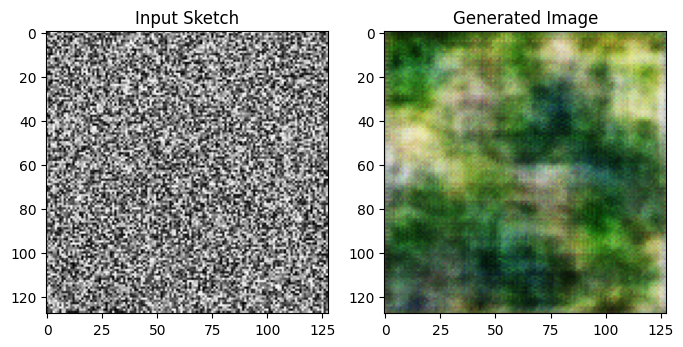

In [82]:
# generate random 128x128 noise using numpy
random_noise = (np.random.rand(128, 128) * 255).astype(np.uint8)
blank_image = Image.fromarray(random_noise, mode="L")


# show input image and output image side by side using matplotlib
fig, axs = plt.subplots(1, 2, figsize=(8, 4))
axs[0].imshow(blank_image, cmap="gray")
axs[0].set_title("Input Sketch")
generated_image = generate_from_sketch(blank_image)
axs[1].imshow(generated_image)
axs[1].set_title("Generated Image")
plt.show()

<PIL.Image.Image image mode=L size=128x128 at 0x27719FE4370>
<class 'PIL.Image.Image'>


C:\Users\EGE\AppData\Local\Temp\ipykernel_36856\1982945196.py:4: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  rectangle_image = Image.fromarray(rectangle_in_middle, mode="L")


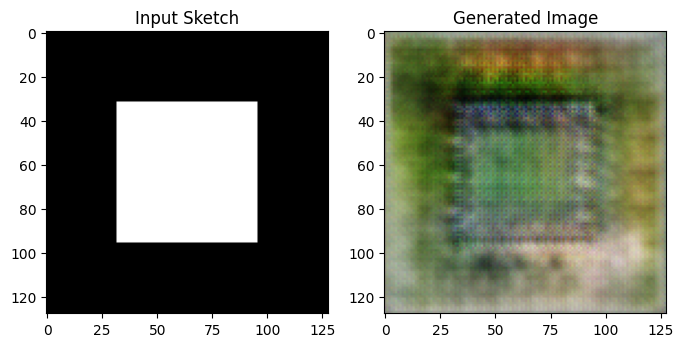

In [83]:
# generate random 128x128 noise using numpy
rectangle_in_middle = np.zeros((128, 128), dtype=np.uint8)
rectangle_in_middle[32:96, 32:96] = 255
rectangle_image = Image.fromarray(rectangle_in_middle, mode="L")


# show input image and output image side by side using matplotlib
fig, axs = plt.subplots(1, 2, figsize=(8, 4))
axs[0].imshow(rectangle_image, cmap="gray")
axs[0].set_title("Input Sketch")
generated_image = generate_from_sketch(rectangle_image)
axs[1].imshow(generated_image)
axs[1].set_title("Generated Image")
plt.show()

<PIL.Image.Image image mode=L size=128x128 at 0x2771CF7EDF0>
<class 'PIL.Image.Image'>


C:\Users\EGE\AppData\Local\Temp\ipykernel_36856\2526667606.py:4: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  rectangle_image = Image.fromarray(rectangle_in_middle, mode="L")


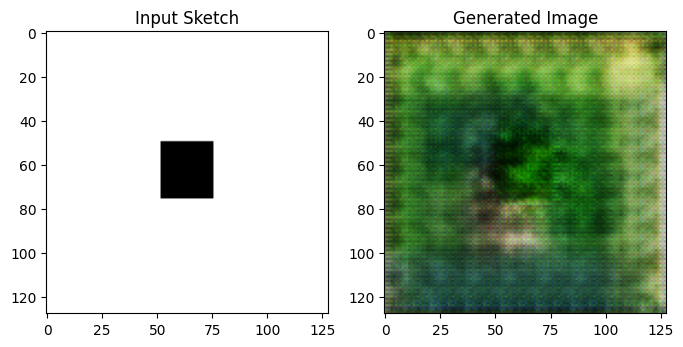

In [84]:
# generate random 128x128 noise using numpy
rectangle_in_middle = np.full((128, 128), 255, dtype=np.uint8)
rectangle_in_middle[50:76, 52:76] = 0
rectangle_image = Image.fromarray(rectangle_in_middle, mode="L")


# show input image and output image side by side using matplotlib
fig, axs = plt.subplots(1, 2, figsize=(8, 4))
axs[0].imshow(rectangle_image, cmap="gray")
axs[0].set_title("Input Sketch")
generated_image = generate_from_sketch(rectangle_image)
axs[1].imshow(generated_image)
axs[1].set_title("Generated Image")
plt.show()

---

In [30]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model_path = "valid_generator_model.pth"  # adjust if needed
G = UNetGenerator().to(device)
state_dict = torch.load(model_path, map_location=device)
G.load_state_dict(state_dict, strict=False)
G.eval()

UNetGenerator(
  (encs): ModuleList(
    (0): Sequential(
      (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): ReLU(inplace=True)
    )
    (1): Sequential(
      (0): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): InstanceNorm2d(128, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
      (2): ReLU(inplace=True)
    )
    (2): Sequential(
      (0): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): InstanceNorm2d(256, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
      (2): ReLU(inplace=True)
    )
    (3): Sequential(
      (0): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): InstanceNorm2d(512, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
      (2): ReLU(inplace=True)
    )
  )
  (decs): ModuleList(
    (0): Sequential(
      (0): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1

<PIL.Image.Image image mode=L size=128x128 at 0x2BF6C0F47D0>
<class 'PIL.Image.Image'>


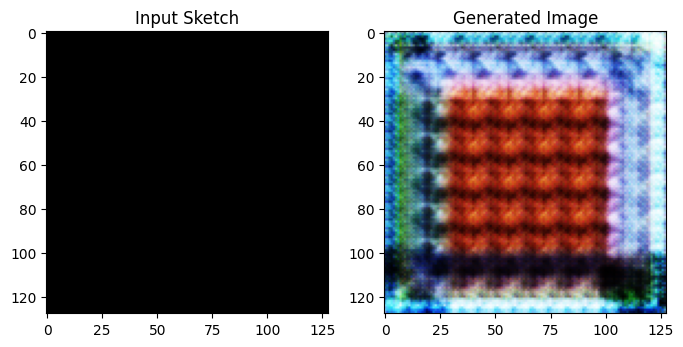

In [31]:
# generate blank 128x128 image
blank_image = Image.new("L", (128, 128), 255)

# show input image and output image side by side using matplotlib
fig, axs = plt.subplots(1, 2, figsize=(8, 4))
axs[0].imshow(blank_image, cmap="gray")
axs[0].set_title("Input Sketch")
generated_image = generate_from_sketch(blank_image)
axs[1].imshow(generated_image)
axs[1].set_title("Generated Image")
plt.show()

<PIL.Image.Image image mode=L size=128x128 at 0x2BF6C2B87D0>
<class 'PIL.Image.Image'>


C:\Users\EGE\AppData\Local\Temp\ipykernel_31688\3302555222.py:2: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  blank_image = Image.fromarray(random_noise, mode="L")


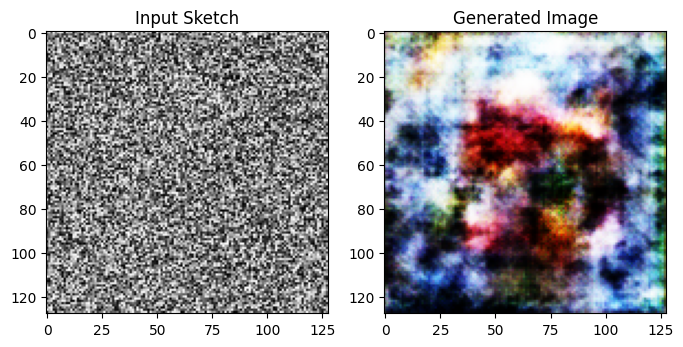

In [32]:
random_noise = (np.random.rand(128, 128) * 255).astype(np.uint8)
blank_image = Image.fromarray(random_noise, mode="L")
# show input image and output image side by side using matplotlib
fig, axs = plt.subplots(1, 2, figsize=(8, 4))
axs[0].imshow(blank_image, cmap="gray")
axs[0].set_title("Input Sketch")
generated_image = generate_from_sketch(blank_image)
axs[1].imshow(generated_image)
axs[1].set_title("Generated Image")
plt.show()

<PIL.Image.Image image mode=L size=128x128 at 0x2BF6C2BB930>
<class 'PIL.Image.Image'>


C:\Users\EGE\AppData\Local\Temp\ipykernel_31688\1982945196.py:4: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  rectangle_image = Image.fromarray(rectangle_in_middle, mode="L")


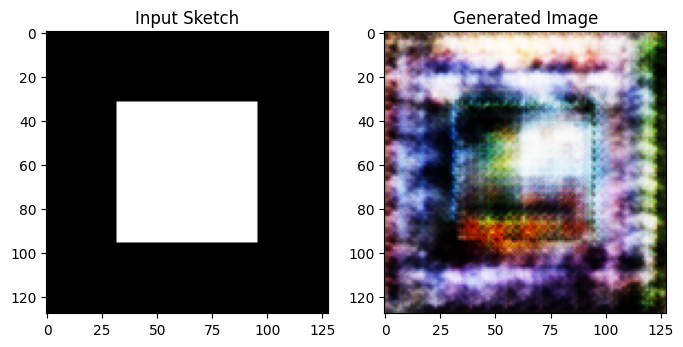

In [34]:
# generate random 128x128 noise using numpy
rectangle_in_middle = np.zeros((128, 128), dtype=np.uint8)
rectangle_in_middle[32:96, 32:96] = 255
rectangle_image = Image.fromarray(rectangle_in_middle, mode="L")


# show input image and output image side by side using matplotlib
fig, axs = plt.subplots(1, 2, figsize=(8, 4))
axs[0].imshow(rectangle_image, cmap="gray")
axs[0].set_title("Input Sketch")
generated_image = generate_from_sketch(rectangle_image)
axs[1].imshow(generated_image)
axs[1].set_title("Generated Image")
plt.show()

<PIL.Image.Image image mode=L size=128x128 at 0x2BF6C2BA350>
<class 'PIL.Image.Image'>


C:\Users\EGE\AppData\Local\Temp\ipykernel_31688\2526667606.py:4: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  rectangle_image = Image.fromarray(rectangle_in_middle, mode="L")


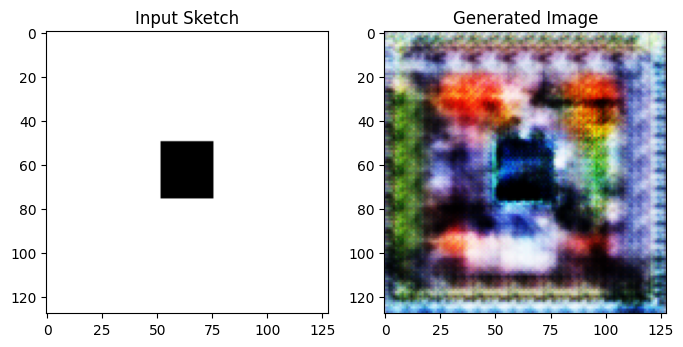

In [33]:
# generate random 128x128 noise using numpy
rectangle_in_middle = np.full((128, 128), 255, dtype=np.uint8)
rectangle_in_middle[50:76, 52:76] = 0
rectangle_image = Image.fromarray(rectangle_in_middle, mode="L")


# show input image and output image side by side using matplotlib
fig, axs = plt.subplots(1, 2, figsize=(8, 4))
axs[0].imshow(rectangle_image, cmap="gray")
axs[0].set_title("Input Sketch")
generated_image = generate_from_sketch(rectangle_image)
axs[1].imshow(generated_image)
axs[1].set_title("Generated Image")
plt.show()